## Thực hành 2: Làm quen với Python và SQL

### Python - Numpy

### NumPy là gì? Tại sao phải dùng NumPy?
NumPy (viết tắt của Numerical Python) là thư viện nền tảng cho mọi tính toán toán học và khoa học dữ liệu trong Python. Bản thân thư viện Pandas (giúp bạn tạo ra các DataFrame chứa bảng dữ liệu ở trên) cũng được xây dựng hoàn toàn trên nền tảng của NumPy.

* Tại sao không dùng List của Python? List của Python rất linh hoạt nhưng chạy cực kỳ chậm khi dữ liệu lên tới hàng triệu dòng. NumPy sử dụng ndarray (mảng N-chiều) được viết bằng ngôn ngữ C, giúp tính toán nhanh hơn gấp 100 đến 1000 lần và tiết kiệm bộ nhớ máy tính tối đa.

BÀI LAB 1: PHÂN TÍCH DỮ LIỆU BẢO TRÌ DỰ ĐOÁN BẰNG THƯ VIỆN NUMPY
Khởi tạo cấu hình và nạp dữ liệu ban đầuTrước khi đi vào các tác vụ phân tích, chúng ta cần khai báo đường dẫn tập dữ liệu và nạp dữ liệu từ file CSV vào bộ nhớ bằng thư viện Pandas, sau đó sẽ dùng NumPy để xử lý chuyên sâu.


In [3]:
import numpy as np
import pandas as pd

In [1]:
import pandas as pd
import numpy as np

# Đường dẫn đến các file dữ liệu (Cần chỉnh sửa lại cho đúng với máy của bạn)
file_ai4i = r"C:\Users\Admin\Desktop\Project\DataAnalytics\Lab1\ai4i2020.csv"
file_steel = r"C:\Users\Admin\Desktop\Project\DataAnalytics\Lab1\steel_plates_faults_original_dataset.csv"

# Đọc file dữ liệu AI4I 2020 Predictive Maintenance bằng Pandas
df_ai4i = pd.read_csv(file_ai4i)

Task 1: Chuyển đổi dữ liệu sang Mảng NumPy (np.array)
- Trong phân tích dữ liệu lớn và khoa học dữ liệu, để thực hiện các phép toán số học phức tạp với tốc độ cực nhanh, chúng ta cần chuyển đổi các cột dữ liệu đơn lẻ thành cấu trúc mảng của NumPy (được gọi là ndarray)
- Chức năng của hàm np.array(): Chuyển đổi một cấu trúc dữ liệu có sẵn (như List của Python hoặc Series của Pandas) thành một mảng NumPy (np.array).Cơ chế hoạt động, NumPy sẽ cấp phát một vùng nhớ liên tục để lưu trữ các phần tử có cùng kiểu dữ liệu. Điều này giúp tối ưu hóa bộ nhớ và tăng tốc độ tính toán lên gấp hàng trăm lần so với vòng lặp Python truyền thống.
- Cách dùng: np.array(du_lieu_dau_vao)

In [22]:
# Lấy cột Nhiệt độ không khí và chuyển sang mảng NumPy
air_temp_array = np.array(df_ai4i['Air temperature [K]'])

print("--- TASK 1: CHUYỂN ĐỔI SANG MẢNG NUMPY ---")
print(f"- Đã chuyển cột 'Air temperature [K]' thành mảng NumPy.")
print(f"- Kiểu dữ liệu của mảng: {type(air_temp_array)}")
print(f"- 5 phần tử đầu tiên của mảng: {air_temp_array[:5]}\n")

--- TASK 1: CHUYỂN ĐỔI SANG MẢNG NUMPY ---
- Đã chuyển cột 'Air temperature [K]' thành mảng NumPy.
- Kiểu dữ liệu của mảng: <class 'numpy.ndarray'>
- 5 phần tử đầu tiên của mảng: [298.1 298.2 298.1 298.2 298.2]



Task 2: Phép toán Vector hóa (Tính toán đồng loạt không dùng vòng lặp)
- Bộ dữ liệu ghi nhận nhiệt độ của nhà máy theo thang đo độ Kelvin (°K). Tuy nhiên, tại Việt Nam và nhiều nước khác, các kỹ sư vận hành máy móc quen thuộc hơn với thang đo độ Celsius (°C). Chúng ta cần quy đổi toàn bộ hàng nghìn dòng dữ liệu nhiệt độ sang độ C.
- Chức năng của Vectorization: Thực hiện các phép toán số học (cộng, trừ, nhân, chia) trực tiếp trên toàn bộ mảng cùng một lúc mà không cần viết vòng lặp for. Cơ chế hoạt động, khi bạn lấy một mảng NumPy trừ đi một hằng số, NumPy tự động áp dụng phép trừ đó cho từng phần tử trong mảng (Cơ chế này gọi là Broadcasting).
- Cách dùng: mang_new = mang_cu - hang_so hoặc mang_moi = mang_1 + mang_2

In [ ]:
# Phép toán Vector hóa (Tính toán đồng loạt không dùng vòng lặp)
# Yêu cầu: Đổi toàn bộ mảng nhiệt độ từ độ K sang độ C (Công thức: Độ C = Độ K - 273.15)
air_temp_celsius = air_temp_array - 273.15
print(f"- 5 phần tử đầu tiên sau khi đổi sang độ C: {air_temp_celsius[:5]}\n")

- 5 phần tử đầu tiên sau khi đổi sang độ C: [24.95 25.05 24.95 25.05 25.05]



Task 3: Tính toán Thống kê Cơ bản với np.mean()
- Để đánh giá môi trường làm việc tổng thể của nhà máy có quá nóng hay không, người quản lý cần biết giá trị nhiệt độ trung bình là bao nhiêu. Điều này giúp đưa ra quyết định có nên lắp đặt thêm hệ thống làm mát trung tâm hay không.
- Chức năng của hàm np.mean(): Tính giá trị trung bình cộng (Mean/Average) của tất cả các phần tử số có trong mảng dữ liệu.Cơ chế hoạt động, hàm sẽ cộng tổng tất cả các phần tử trong mảng lại, sau đó chia cho tổng số lượng phần tử.
- Cách dùng: np.mean(mang_du_lieu)

In [5]:
#Thống kê cơ bản với np.mean() và np.sum()
# Tính nhiệt độ trung bình của nhà máy
mean_temp = np.mean(air_temp_array)
print(f"- Nhiệt độ không khí trung bình (độ K): {mean_temp:.2f} K")
print(f"- Nhiệt độ không khí trung bình (độ C): {np.mean(air_temp_celsius):.2f} °C")

- Nhiệt độ không khí trung bình (độ K): 300.00 K
- Nhiệt độ không khí trung bình (độ C): 26.85 °C


Task 4: Tìm giá trị Cực trị bằng np.max() và np.min()
- Mỗi loại máy móc trong nhà máy đều có một giới hạn vận hành an toàn về tốc độ quay (Rotational speed). Nếu máy quay quá chậm, năng suất sẽ giảm. Ngược lại, nếu máy quay quá nhanh vượt ngưỡng thiết kế, linh kiện sẽ bị mài mòn rất nhanh và có nguy cơ nổ vỡ. Chúng ta cần tìm ra các giá trị biên (lớn nhất và nhỏ nhất) đã từng xuất hiện trong lịch sử vận hành.
- Chức năng của hàm np.max() & np.min(): Tìm ra giá trị lớn nhất (np.max) và giá trị nhỏ nhất (np.min) có trong mảng dữ liệu.
- Cách dùng:
    + np.max(mang_du_lieu): Trả về phần tử có giá trị cao nhất
    + np.min(mang_du_lieu): Trả về phần tử có giá trị thấp nhất.

In [6]:
# Tìm giá trị Cực trị bằng np.max() và np.min()
rot_speed_array = np.array(df_ai4i['Rotational speed [rpm]'])

max_speed = np.max(rot_speed_array)
min_speed = np.min(rot_speed_array)

print(f"- Tốc độ quay lớn nhất của máy móc (np.max): {max_speed} rpm")
print(f"- Tốc độ quay nhỏ nhất của máy móc (np.min): {min_speed} rpm\n")

- Tốc độ quay lớn nhất của máy móc (np.max): 2886 rpm
- Tốc độ quay nhỏ nhất của máy móc (np.min): 1168 rpm



Task 5: Tính Độ lệch chuẩn bằng np.std() để đo độ ổn định
- Lực xoắn (Torque) tác động lên trục máy là một chỉ số cần sự ổn định. Nếu lực xoắn lúc quá cao, lúc quá thấp (trồi sụt thất thường), máy sẽ bị rung lắc mạnh và dễ hỏng. Chỉ biết giá trị trung bình là chưa đủ, kỹ sư cần biết dữ liệu có bị phân tán, dao động mạnh hay không.
- Chức năng của hàm np.std(): Tính độ lệch chuẩn (Standard Deviation) của mảng dữ liệu. Đây là thước đo mức độ phân tán của các giá trị xung quanh số trung bình.Ý nghĩa thực tế:Độ lệch chuẩn nhỏ: Các giá trị rất sát với mức trung bình → Máy hoạt động ổn định.Độ lệch chuẩn lớn: Các giá trị dao động xa mức trung bình → Máy hoạt động chập chờn, bất ổn định.
- Cách dùng: np.std(mang_du_lieu)

In [7]:
# Tính Độ lệch chuẩn bằng np.std() để đo độ ổn định
torque_array = np.array(df_ai4i['Torque [Nm]'])

std_torque = np.std(torque_array)
print(f"- Lực xoắn trung bình: {np.mean(torque_array):.2f} Nm")
print(f"- Độ phân tán/Độ lệch chuẩn lực xoắn (np.std): {std_torque:.2f} Nm")
print("- Nhận xét: Lực xoắn của máy thường biến thiên xung quanh mức trung bình +/- độ lệch chuẩn này.\n")


- Lực xoắn trung bình: 39.99 Nm
- Độ phân tán/Độ lệch chuẩn lực xoắn (np.std): 9.97 Nm
- Nhận xét: Lực xoắn của máy thường biến thiên xung quanh mức trung bình +/- độ lệch chuẩn này.



Task 6: Đếm số lượng sự cố bằng np.sum() kết hợp Điều kiện
- Cột dữ liệu Machine failure (Hỏng máy) chứa các giá trị nhị phân: 1 đại diện cho việc máy bị hỏng tại thời điểm đó, và 0 là máy hoạt động bình thường. Chúng ta cần đếm tổng số ca hỏng máy để báo cáo cho phòng bảo trì. Đồng thời, cần điều tra sâu hơn xem có bao nhiêu ca hỏng máy xảy ra khi thời tiết quá oi bức (Nhiệt độ môi trường > 300°K).
- Chức năng của np.sum() kết hợp Mặt nạ Điều kiện (Boolean Mask): Tính tổng các phần tử trong mảng. Khi kết hợp với biểu thức logic (như >, <, ==), NumPy sẽ tạo ra mảng chứa các giá trị True (đúng) và False (sai).
- Cơ chế hoạt động: Trong toán học máy tính, True tương đương với 1 và False tương đương với 0. Vì vậy, khi dùng np.sum() trên một mảng điều kiện, bản chất là chúng ta đang cộng tất cả các giá trị 1 (True) lại, từ đó ra được số lượng phần tử thỏa mãn điều kiện.
- Phép toán logic nhiều điều kiện: Sử dụng dấu & cho điều kiện ĐỒNG THỜI XẢY RA (VÀ) và dấu | cho điều kiện HOẶC. Lưu ý phải bọc các mệnh đề trong dấu ngoặc đơn ()

In [9]:
# Đếm số lượng sự cố bằng np.sum() kết hợp Điều kiện
failure_array = np.array(df_ai4i['Machine failure'])

# Tính tổng số ca hỏng máy (Cột failure nhận giá trị 0 hoặc 1)
total_failures = np.sum(failure_array)
print(f"- Tổng số ca thiết bị gặp sự cố hỏng hóc trong nhà máy: {total_failures} ca")

# Đếm xem có bao nhiêu máy đang hoạt động ở mức nhiệt độ quá cao (> 300 K) mà bị hỏng
high_temp_failures = np.sum((air_temp_array > 300) & (failure_array == 1))
print(f"- Số ca hỏng máy xảy ra khi nhiệt độ môi trường vượt quá 300K: {high_temp_failures} ca\n")

- Tổng số ca thiết bị gặp sự cố hỏng hóc trong nhà máy: 339 ca
- Số ca hỏng máy xảy ra khi nhiệt độ môi trường vượt quá 300K: 230 ca



Task 7: Tính Tỷ lệ phần trăm sự cố bằng np.mean()
- Thay vì chỉ biết số ca hỏng thô (ví dụ: 339 ca), ban giám đốc cần một con số mang tính so sánh chung như: "Tỷ lệ hỏng hóc của nhà máy chiếm bao nhiêu phần trăm trên tổng số số giờ vận hành?". Con số phần trăm này giúp doanh nghiệp so sánh mức độ an toàn với các nhà máy khác trong ngành.
- Chức năng và Cách dùng mẹo với hàm np.mean(): Đối với một mảng dữ liệu nhị phân chỉ toàn số 0 và 1, hàm np.mean() ngoài tính trung bình cộng thì nó phản ánh chính xác tỷ lệ xuất hiện của các số 1.Cơ chế hoạt động: Trung bình = (Tổng các số 1) / (Tổng số lượng phần tử 0 và 1). Đây chính là công thức tính tỷ lệ phần trăm phần tử đạt điều kiện.
- Cách dùng: np.mean(mang_nhi_phan) rồi nhân với 100 để đổi ra đơn vị %.

In [10]:
# Tính Tỷ lệ phần trăm sự cố bằng np.mean()
# Với mảng chứa giá trị nhị phân 0 và 1, hàm np.mean() chính là tỷ lệ xuất hiện của giá trị 1
failure_rate = np.mean(failure_array)

print(f"- Tỷ lệ hỏng hóc trung bình của toàn bộ nhà máy: {failure_rate:.4f}")
print(f"- Quy đổi sang phần trăm: {failure_rate * 100:.2f}%\n")

- Tỷ lệ hỏng hóc trung bình của toàn bộ nhà máy: 0.0339
- Quy đổi sang phần trăm: 3.39%



Task 8: Lọc dữ liệu mảng bằng kỹ thuật Boolean Indexing
- Khi hệ thống cảnh báo có hàng trăm máy gặp sự cố, kỹ sư không thể ngồi dò từng dòng để xem cấu hình vận hành của riêng những máy hỏng đó. Ban kỹ thuật cần tách ngay toàn bộ dữ liệu tốc độ quay của nhóm máy lỗi ra một danh sách riêng. Mục tiêu là phân tích xem có phải tốc độ quá cao là nguyên nhân gây hỏng hóc hay không.

- Chức năng đặc biệt: Kỹ thuật dùng một mảng điều kiện Đúng/Sai (True/False) làm "bộ lọc" để trích xuất các phần tử từ một mảng khác có cùng kích thước.
* Cơ chế hoạt động: Khi bạn truyền biểu thức failure_array == 1 vào trong dấu ngoặc vuông của mảng tốc độ, NumPy sẽ quét qua từng vị trí. Chỉ những vị trí nào ứng với số 1 (Máy hỏng - True) thì giá trị tốc độ tại đó mới được giữ lại.
* Cách dùng: mang_can_loc[mang_dieu_kien == gia_tri]. Kết quả trả về là một mảng mới ngắn hơn, chỉ chứa dữ liệu thỏa mãn điều kiện.


In [11]:
# Lọc dữ liệu mảng bằng kỹ thuật Boolean Indexing
# Lọc lấy danh sách tốc độ quay của riêng những máy đã bị hỏng
speed_of_failed_machines = rot_speed_array[failure_array == 1]

print(f"- Số lượng mẫu máy hỏng thu được: {len(speed_of_failed_machines)}")
print(f"- Tốc độ quay trung bình của riêng nhóm máy bị hỏng này: {np.mean(speed_of_failed_machines):.2f} rpm\n")

- Số lượng mẫu máy hỏng thu được: 339
- Tốc độ quay trung bình của riêng nhóm máy bị hỏng này: 1496.49 rpm



Task 9: Phân nhóm dữ liệu bằng np.percentile() để tìm ngoại lai
- Để thiết lập ngưỡng cảnh báo sớm cho thiết bị, phòng bảo trì không thể chọn đại một con số cảm tính. Họ cần biết mức lực xoắn (torque) thực tế mà đại đa số các máy đang chịu đựng là bao nhiêu. Việc xác định được mốc giới hạn mà 95% số máy vận hành dưới mức đó giúp doanh nghiệp cô lập được 5% nhóm máy "cá biệt" đang chạy quá tải để lên lịch bảo dưỡng nghiêm ngặt.

- Chức năng và Cách dùng mẹo với hàm np.percentile()
* Chức năng đặc biệt: Hàm giúp tìm giá trị phân vị (Percentile), tức là điểm mốc chia dữ liệu thành hai phần theo tỷ lệ phần trăm mong muốn sau khi đã sắp xếp từ thấp đến cao.
* Cơ chế hoạt động: Khi truyền vào con số 95, NumPy sẽ tính toán ra một giá trị lực xoắn cụ thể. Tại giá trị này, dữ liệu sẽ chia làm 2 phe rõ rệt: 95% số máy có lực xoắn thấp hơn hoặc bằng nó, và chỉ 5% số máy có lực xoắn cao hơn nó.
* Cách dùng: np.percentile(mang_du_lieu, phan_tram). Trong đó phan_tram nhận giá trị từ 0 đến 100.

In [12]:
# Phân nhóm dữ liệu bằng np.percentile() để tìm ngoại lai
# Tìm mức giới hạn mà 95% số máy có lực xoắn thấp hơn mức này
torque_95th = np.percentile(torque_array, 95)

print(f"- Mức phân vị thứ 95 của lực xoắn: {torque_95th:.2f} Nm")
print(f"- Ý nghĩa: Chỉ có 5% số máy trong nhà máy vận hành với lực xoắn cực đại vượt quá {torque_95th:.2f} Nm (Nguy cơ quá tải).\n")


- Mức phân vị thứ 95 của lực xoắn: 56.10 Nm
- Ý nghĩa: Chỉ có 5% số máy trong nhà máy vận hành với lực xoắn cực đại vượt quá 56.10 Nm (Nguy cơ quá tải).



Task 10: Làm sạch dữ liệu bằng np.clip() (Giới hạn biên)
- Cảm biến nhiệt độ hoặc tốc độ trong nhà máy đôi khi bị nhiễu do sóng từ trường, sinh ra các giá trị ảo cực đoan (ví dụ tốc độ vọt lên 5000 rpm hoặc âm vài trăm rpm trong tích tắc). Nếu đưa trực tiếp dữ liệu rác này vào mô hình AI, máy tính sẽ dự báo sai hoàn toàn. Doanh nghiệp cần một "hàng rào kỹ thuật" để ép các giá trị vượt khung này về đúng biên độ thực tế quy định (1200 rpm đến 2000 rpm).

- Chức năng và Cách dùng mẹo với hàm np.clip()
* Chức năng đặc biệt: Hàm này hoạt động như một cái khuôn cắt biên dữ liệu, tự động "gọt" phẳng các phần tử vượt ngưỡng mà không làm thay đổi các giá trị đã nằm trong vùng an toàn.
* Cơ chế hoạt động: NumPy duyệt qua mảng: phần tử nào nhỏ hơn ngưỡng dưới sẽ bị ép bằng ngưỡng dưới; phần tử nào lớn hơn ngưỡng trên sẽ bị ép bằng ngưỡng trên; các phần tử ở giữa được giữ nguyên.
* Cách dùng: np.clip(mang_du_lieu, nguong_duoi, nguong_tren). Đây là giải pháp làm sạch dữ liệu cực nhanh thay vì phải viết nhiều vòng lặp if-else phức tạp.

In [13]:
# Làm sạch dữ liệu bằng np.clip() (Giới hạn biên)
# Giả sử quy định tốc độ quay không được quá 2000 rpm và không dưới 1200 rpm để tránh nhiễu cảm biến
cleaned_speed = np.clip(rot_speed_array, 1200, 2000)

print(f"- Tốc độ tối đa ban đầu: {np.max(rot_speed_array)} rpm")
print(f"- Tốc độ tối đa sau khi xử lý cắt biên (np.clip): {np.max(cleaned_speed)} rpm")

- Tốc độ tối đa ban đầu: 2886 rpm
- Tốc độ tối đa sau khi xử lý cắt biên (np.clip): 2000 rpm


### Python - Pandas

### Pandas là gì? Tại sao phải dùng Pandas?
Pandas (viết tắt của Panel Data) là thư viện tối quan trọng trong Python chuyên dùng để thao tác, làm sạch và phân tích dữ liệu dưới dạng bảng. Nếu NumPy cung cấp sức mạnh tính toán mảng mạnh mẽ ở bên dưới, thì Pandas chính là giao diện "Excel chạy bằng code" giúp bạn dễ dàng quản lý hàng triệu dòng dữ liệu có cấu trúc.

* Tại sao không dùng Excel hay SQL? Excel sẽ bị treo hoặc sập nguồn khi tệp dữ liệu vượt quá 1 triệu dòng và không thể tự động hóa các tác vụ phức tạp. SQL rất mạnh để truy vấn nhưng lại hạn chế trong việc làm sạch dữ liệu chuyên sâu và trực quan hóa đồ thị. Pandas kết hợp sức mạnh của cả hai: xử lý dữ liệu khổng lồ với tốc độ cực nhanh, quản lý linh hoạt bằng hai cấu trúc chính là Series (mảng 1 chiều có nhãn) và DataFrame (bảng 2 chiều có hàng và cột).

BÀI LAB 2: THAO TÁC VÀ LÀM SẠCH DỮ LIỆU NHÀ MÁY BẰNG THƯ VIỆN PANDAS
- Khởi tạo cấu hình và nạp dữ liệu ban đầu: Để bắt đầu chiến dịch chuẩn hóa dữ liệu vận hành, chúng ta sẽ sử dụng Pandas để đọc trực tiếp file dữ liệu thô (CSV/Excel). Thư viện này sẽ tự động chuyển đổi các hàng và cột thô thành một DataFrame trực quan, sẵn sàng cho các bước lọc nhiễu, xử lý dữ liệu trống (Missing data) và trích xuất thông tin nghiệp vụ.


In [17]:
import os
import pandas as pd

# Đọc và in ra 5 hàng đầu tiên (df.head())
df = pd.read_csv(file_ai4i)

# In ra 5 hàng đầu tiên
display(df.head())


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Task 1: Đọc và kiểm tra nhanh dữ liệu bằng pd.read_csv() và df.head()
- Trước khi bắt tay vào phân tích hay xây dựng mô hình AI, bước đầu tiên và quan trọng nhất là phải "nhìn thấy" dữ liệu. Bạn cần biết tập dữ liệu gồm những cột nào, kiểu dữ liệu ra sao và hình thù các dòng đầu tiên như thế nào. Việc in ra một vài hàng đầu tiên giúp kỹ sư xác nhận dữ liệu đã được nạp đúng cấu trúc, không bị lỗi font hay lệch cột.
Chức năng và Cách dùng mẹo với hàm trong Pandas

* Hàm pd.read_csv():
* Chức năng: Tự động quét qua file CSV, nhận diện các hàng, cột và dấu phân cách để chuyển đổi toàn bộ tệp văn bản thô đó thành một bảng dữ liệu thông minh (DataFrame).
   * Cách dùng: pd.read_csv(duong_dan_file).
* Phương thức df.head():
* Chức năng: Trích xuất nhanh một số dòng đầu tiên của bảng dữ liệu để xem trước (mặc định là 5 dòng).
   * Cơ chế hoạt động: Thay vì bắt máy tính phải hiển thị toàn bộ hàng triệu dòng gây lag màn hình, df.head() chỉ cắt lấy phần ngọn của bảng, giúp bạn kiểm tra nhanh cấu trúc dữ liệu mà không tốn tài nguyên.
   * Cách dùng: df.head(so_dong) (Nếu để trống sẽ tự động lấy 5 dòng, hoặc bạn có thể điền số dòng mong muốn như df.head(10)).

In [19]:
# Quan sát cấu trúc dữ liệu với df.shape và df.info()
# df.shape trả về (số dòng, số cột)
print(f"- Kích thước tập dữ liệu (df.shape): {df.shape[0]} dòng và {df.shape[1]} cột.\n")

# df.info() in ra kiểu dữ liệu của từng cột và số lượng dòng có dữ liệu (Non-Null)
print("- Chi tiết cấu trúc các cột (df.info()):")
df.info()
print("\n")

- Kích thước tập dữ liệu (df.shape): 10000 dòng và 14 cột.

- Chi tiết cấu trúc các cột (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000

In [21]:
# Thống kê mô tả đơn giản bằng df.describe()
# Tự động tính toán cho tất cả các cột số thực/số nguyên trong bảng
display(df.describe())


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [22]:
# Thống kê giá trị trung bình cụ thể bằng df['cột'].mean()
# Tính nhiệt độ không khí trung bình
mean_air_temp = df['Air temperature [K]'].mean()
print(f"- Nhiệt độ không khí trung bình (độ K): {mean_air_temp:.2f} K")

# Tạo cột mới đổi sang độ C trực tiếp trên DataFrame và tính trung bình
df['Air temperature [C]'] = df['Air temperature [K]'] - 273.15
print(f"- Nhiệt độ không khí trung bình (độ C): {df['Air temperature [C]'].mean():.2f} °C\n")


- Nhiệt độ không khí trung bình (độ K): 300.00 K
- Nhiệt độ không khí trung bình (độ C): 26.85 °C



In [ ]:
# Đếm tổng số ca hỏng máy bằng df['cột'].sum()
total_failures = df['Machine failure'].sum()
print(f"- Tổng số ca máy bị hỏng ghi nhận trong nhà máy (df.sum): {total_failures} ca\n")

- Tổng số ca máy bị hỏng ghi nhận trong nhà máy (df.sum): 339 ca



In [24]:
# Thống kê tần suất danh mục bằng df['cột'].value_counts()
# Lấy ra ký tự đầu tiên (L, M, H) trong cột Product ID để đếm loại máy
df['Type'] = df['Product ID'].str[0]
type_counts = df['Type'].value_counts()

print("- Số lượng máy móc theo từng phân cấp chất lượng:")
for product_type, count in type_counts.items():
    print(f"  + Loại {product_type} (Low/Medium/High): {count} máy")
print("\n")


- Số lượng máy móc theo từng phân cấp chất lượng:
  + Loại L (Low/Medium/High): 6000 máy
  + Loại M (Low/Medium/High): 2997 máy
  + Loại H (Low/Medium/High): 1003 máy




In [25]:
# Phân nhóm dữ liệu và tính trung bình bằng df.groupby()
# Gom nhóm theo trạng thái hỏng (0 và 1) rồi tính trung bình các cột cảm biến chính
grouped_summary = df.groupby('Machine failure')[['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].mean()
display(grouped_summary)
print("- Nhận xét: Máy bị hỏng thường có lực xoắn (Torque) và thời gian mòn dao (Tool wear) trung bình cao hơn máy bình thường.\n")


,Air temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,
0,299.973999,1540.260014,39.629655,106.693717
1,300.886431,1496.486726,50.168142,143.781711


- Nhận xét: Máy bị hỏng thường có lực xoắn (Torque) và thời gian mòn dao (Tool wear) trung bình cao hơn máy bình thường.



In [26]:
# Thống kê chi tiết 5 loại lỗi cụ thể (Dữ liệu lớn)
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("- Tổng số ca hỏng của từng loại lỗi cụ thể:")
for fault in failure_types:
    print(f"  + Lỗi {fault}: {df[fault].sum()} ca")

- Tổng số ca hỏng của từng loại lỗi cụ thể:
  + Lỗi TWF: 46 ca
  + Lỗi HDF: 115 ca
  + Lỗi PWF: 95 ca
  + Lỗi OSF: 98 ca
  + Lỗi RNF: 19 ca


### SQL

- mình dùng Xampp để mở MySQL, nếu mọi người chưa cài cơ sở dữ liệu SQL nào trên máy thì có thể tải Xampp theo video này (với máy win): https://www.youtube.com/watch?v=UjAbsItMPRY
- sau đó mọi người chỉ cần bật MySQL lên như ảnh dưới là xong và tiếp thục chạy các code ở dưới
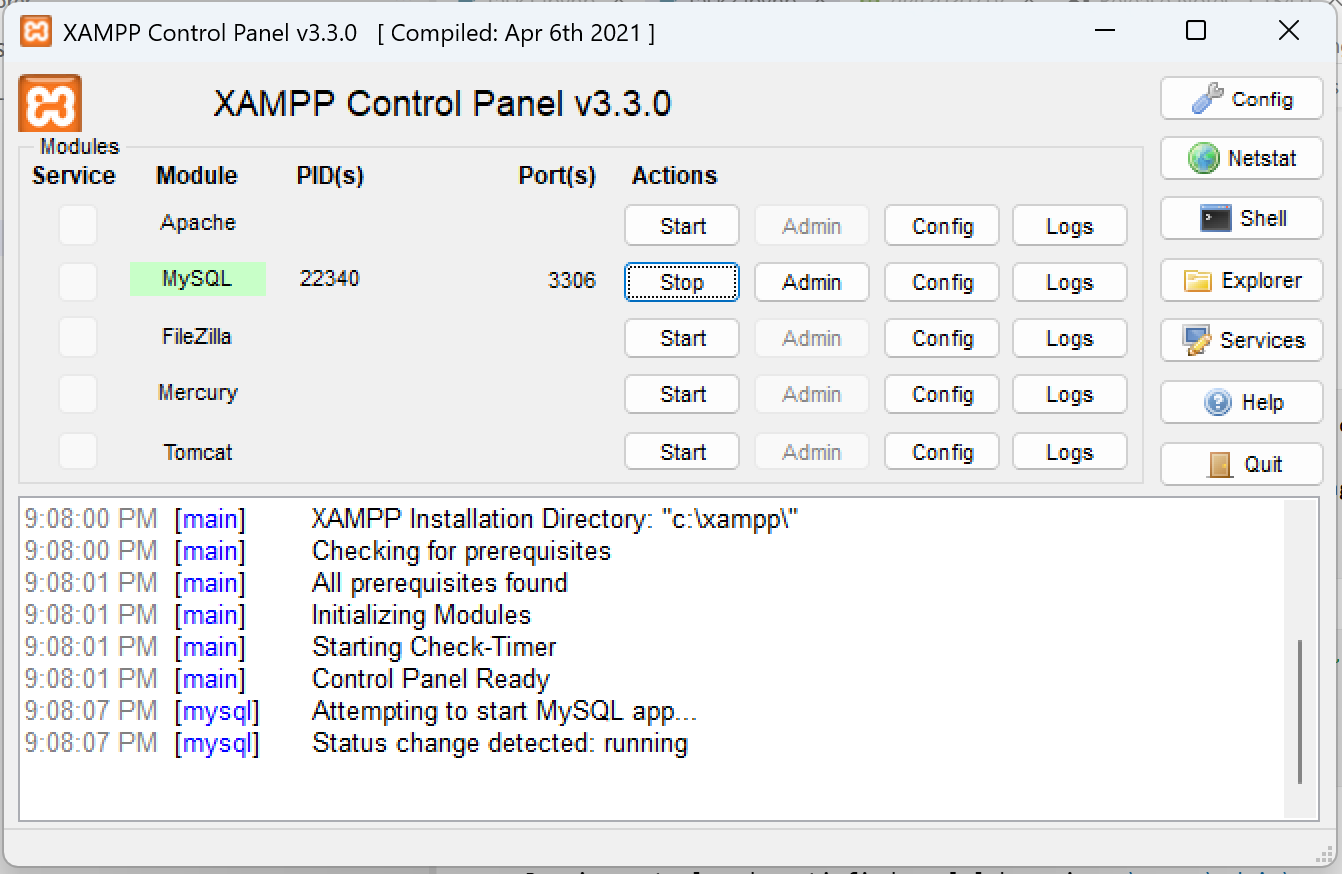

In [5]:
# Cài đặt thư viện kết nối MySQL và bộ tạo cấu trúc cơ sở dữ liệu SQLAlchemy
!pip install pymysql sqlalchemy



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# đẩy dataset vào cơ sở dữ liệu MySQL bằng SQLAlchemy
import os
import pandas as pd
from sqlalchemy import create_engine, text

In [6]:
# 1. Đường dẫn file dữ liệu CSV trên máy của bạn
# file_path = r"C:\Users\Admin\Desktop\Project\DataAnalytics\Lab1\ai4i_2020.csv"
df = pd.read_csv(file_ai4i)

# 2. Làm sạch tên cột (Xóa khoảng trắng, dấu ngoặc vuông để SQL không lỗi cú pháp)
df.columns = df.columns.str.replace(' ', '_').str.replace('[', '').str.replace(']', '')

# 3. Kết nối tới MySQL của XAMPP 
engine_init = create_engine("mysql+pymysql://root:@localhost:3306/")

# 4. GIẢI PHÁP SỬA LỖI: Sử dụng hàm text() để bọc câu lệnh SQL tạo Database
with engine_init.connect() as conn:
    conn.execute(text("CREATE DATABASE IF NOT EXISTS bigdata_lab1;"))
    conn.commit() # Xác nhận lưu thay đổi vào hệ thống database
print("Đã tạo/Kiểm tra Cơ sở dữ liệu 'bigdata_lab1' thành công!")

# 5. Kết nối trực tiếp vào Cơ sở dữ liệu vừa tạo để đổ dữ liệu
engine_db = create_engine("mysql+pymysql://root:@localhost:3306/bigdata_lab1")

print("Đang đẩy 10.000 dòng dữ liệu vào bảng SQL")
# Đẩy toàn bộ DataFrame vào bảng tên là 'predictive_maintenance'
df.to_sql(name='predictive_maintenance', con=engine_db, if_exists='replace', index=False)
print("Thành công! Dữ liệu đã nằm trọn vẹn trong MySQL Server của XAMPP.")



NameError: name 'pd' is not defined

### Dưới đây là hướng dẫn nhanh giúp mn nắm lòng bản chất của các câu lệnh SQL vừa dùng. Hãy tưởng tượng tập dữ liệu của bạn như một bảng Excel lớn, SQL chính là bộ công cụ giúp bạn lọc và tính toán trên bảng đó.
------------------------------
### 1. SELECT & FROM — Chọn cột và Nguồn dữ liệu

* Ý nghĩa: FROM xác định bạn lấy dữ liệu từ bảng nào. SELECT quyết định bạn muốn lấy những cột (trường) nào ra để xem.
* Ví dụ:

SELECT Product_ID, Type FROM predictive_maintenance;

(Lấy danh sách Mã sản phẩm và Loại máy từ bảng bảo trì).
* Mẹo: Dùng SELECT * nếu muốn lấy tất cả các cột, kết hợp LIMIT 10 ở cuối để máy chỉ hiển thị 10 dòng đầu cho nhẹ.

### 2. WHERE — Bộ lọc dòng (Filter)

* Ý nghĩa: Lọc ra các dòng thỏa mãn một điều kiện cụ thể nào đó. Nó hoạt động giống như tính năng Filter trong Excel.
* Ví dụ:

WHERE Machine_failure = 1

(Chỉ giữ lại những dòng mà máy đã bị lỗi, loại bỏ các dòng máy hoạt động bình thường).

### 3. ORDER BY — Sắp xếp dữ liệu (Sort)

* Ý nghĩa: Sắp xếp kết quả trả về theo thứ tự tăng dần hoặc giảm dần dựa trên một cột nào đó.
* Từ khóa đi kèm: ASC (Mặc định - Tăng dần từ nhỏ đến lớn) hoặc DESC (Giảm dần từ lớn đến nhỏ).
* Ví dụ:

ORDER BY Rotational_speed_rpm DESC

(Sắp xếp các máy từ tốc độ quay cao nhất đến thấp nhất).

### 4. GROUP BY & AGGREGATION — Gom cụm và Hàm tổng hợp

* Ý nghĩa:
* GROUP BY gom các dòng có giá trị giống nhau ở một cột thành một nhóm (Giống như Pivot Table trong Excel).
   * Hàm tổng hợp (AGGREGATION) dùng để tính toán ra một con số đại diện cho nhóm đó.
* Các hàm phổ biến: COUNT(*) (Đếm số lượng), SUM() (Tính tổng), AVG() (Tính trung bình), MAX() / MIN() (Tìm số lớn/nhỏ nhất).
* Ví dụ:

SELECT Type, COUNT(*), AVG(Process_temperature_K)FROM predictive_maintenanceGROUP BY Type;

(Gom dữ liệu theo từng Loại máy H, M, L. Sau đó đếm xem mỗi loại có bao nhiêu máy và tính nhiệt độ trung bình của từng loại).

### 5. HAVING — Bộ lọc sau khi gom cụm

* Ý nghĩa: Giống như WHERE, nhưng WHERE dùng để lọc từng dòng thô ban đầu, còn HAVING dùng để lọc kết quả sau khi đã gom cụm bằng GROUP BY.
* Ví dụ:

GROUP BY TypeHAVING SUM(Tool_wear_min) > 500

(Gom nhóm theo loại máy xong, chỉ giữ lại nhóm nào có tổng thời gian hao mòn cộng lại lớn hơn 500 phút).

### 6. INNER JOIN — Liên kết hai bảng

* Ý nghĩa: Khi bạn có 2 bảng dữ liệu khác nhau nhưng có chung một "sợi dây liên kết" (gọi là Khóa - Key), JOIN sẽ giúp bạn gộp các cột của 2 bảng đó lại thành một bảng lớn dựa trên sợi dây này.
* Ví dụ:

FROM predictive_maintenance pINNER JOIN factory_floors f ON p.Product_ID = f.Product_ID

(Nối bảng log vận hành với bảng vị trí phân xưởng. Sợi dây liên kết ở đây là mã Product_ID phải trùng nhau ở cả hai bảng).

### 7. CASE WHEN — Câu lệnh điều kiện (If-Else)

* Ý nghĩa: Giúp bạn tạo ra các giá trị mới hoặc phân loại dữ liệu trực tiếp khi truy vấn dựa trên các điều kiện cho trước (Giống hàm IF trong Excel hay Python).
* Ví dụ:

CASE WHEN Type = 'L' THEN 'Phân xưởng A' ELSE 'Phân xưởng B' END

(Nếu Loại máy là L thì ghi nhận là Phân xưởng A, ngược lại thì ghi là Phân xưởng B).

------------------------------
### Thứ tự chạy của một câu lệnh SQL (Rất quan trọng!)
Khi bạn viết code, bạn viết SELECT đầu tiên. Nhưng trong "não" của máy tính, nó sẽ chạy theo thứ tự sau:

   1. FROM & JOIN (Tìm bảng dữ liệu và nối chúng lại trước)
   2. WHERE (Lọc bỏ các dòng không cần thiết)
   3. GROUP BY (Gom các dòng còn lại thành từng nhóm)
   4. HAVING (Lọc bỏ các nhóm không thỏa mãn)
   5. SELECT (Lấy ra các cột bạn muốn xem và tính toán hàm tổng hợp)
   6. ORDER BY (Sắp xếp lại các dòng kết quả cuối cùng)
   7. LIMIT (Giới hạn số dòng hiển thị)


* Tìm hiểu về Subquery (Truy vấn con) - kỹ thuật lồng một câu lệnh SELECT vào trong một câu lệnh SELECT khác?
* Hay chúng ta chuyển sang vẽ biểu đồ trực quan hóa dữ liệu bằng thư viện Seaborn/Matplotlib từ các bảng SQL này?




In [31]:
# Kết nối và đọc thử dữ liệu bằng câu lệnh SQL thuần túy
query_sql = "SELECT * FROM predictive_maintenance LIMIT 5;"

df_from_sql = pd.read_sql(query_sql, con=engine_db)
print("--- 5 DÒNG DỮ LIỆU ĐỌC TRỰC TIẾP TỪ SQL SERVER ---")
display(df_from_sql)

--- 5 DÒNG DỮ LIỆU ĐỌC TRỰC TIẾP TỪ SQL SERVER ---


,UDI,Product_ID,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


1. Lọc dữ liệu (WHERE) kết hợp Sắp xếp (ORDER BY)Bài toán: Tìm Top 10 máy có nhiệt độ quy trình (Process temperature) cao nhất trong số các máy bị lỗi (Failure = 1) để kiểm tra xem nhiệt độ có phải là nguyên nhân chính gây lỗi hay không.

In [10]:
# Kiểm tra tên cột thực tế trong MySQL
inspect_df = pd.read_sql("SELECT * FROM predictive_maintenance LIMIT 1;", con=engine_db)
print(inspect_df.columns.tolist())

['UDI', 'Product_ID', 'Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [11]:
query_where_orderby = """
SELECT UDI, Product_ID, Type, Rotational_speed_rpm, Machine_failure
FROM predictive_maintenance
WHERE Machine_failure = 1 
ORDER BY Rotational_speed_rpm DESC
LIMIT 10;
"""

df_high_speed_failures = pd.read_sql(query_where_orderby, con=engine_db)
print("--- TOP 10 MÁY BỊ LỖI CÓ TỐC ĐỘ QUAY CAO NHẤT ---")
display(df_high_speed_failures)


--- TOP 10 MÁY BỊ LỖI CÓ TỐC ĐỘ QUAY CAO NHẤT ---


,UDI,Product_ID,Type,Rotational_speed_rpm,Machine_failure
0,1785,L48964,L,2886,1
1,464,L47643,L,2874,1
2,51,L47230,L,2861,1
3,848,L48027,L,2833,1
4,4297,L51476,L,2825,1
5,3370,L50549,L,2760,1
6,1392,L48571,L,2737,1
7,1096,L48275,L,2721,1
8,7998,M22857,M,2710,1
9,3868,M18727,M,2709,1


2. Gom cụm (GROUP BY) & Hàm tổng hợp (AGGREGATION)Bài toán: Thống kê tổng số máy, số lượng máy lỗi, nhiệt độ quy trình trung bình (Process temperature) và thời gian hao mòn công cụ lớn nhất (Tool wear) theo từng loại máy (Type - gồm H, M, L).

In [12]:
query_groupby = """
SELECT 
    Type AS Loai_May,
    COUNT(*) AS Tong_So_May,
    SUM(Machine_failure) AS So_May_Bi_Loi,
    AVG(Process_temperature_K) AS Nhiet_Do_Quy_Trinh_TB,
    MAX(Tool_wear_min) AS Thoi_Gian_Hao_Mon_Max
FROM predictive_maintenance
GROUP BY Type;
"""

df_summary = pd.read_sql(query_groupby, con=engine_db)
print("--- THỐNG KÊ HIỆU SUẤT VÀ LỖI THEO LOẠI MÁY ---")
display(df_summary)


--- THỐNG KÊ HIỆU SUẤT VÀ LỖI THEO LOẠI MÁY ---


,Loai_May,Tong_So_May,So_May_Bi_Loi,Nhiet_Do_Quy_Trinh_TB,Thoi_Gian_Hao_Mon_Max
0,H,1003,21.0,309.925723,246
1,L,6000,235.0,310.012300,251
2,M,2997,83.0,310.018785,253


3. Điều kiện sau gom cụm (HAVING)Bài toán: Tìm các nhóm máy (Type) mà trong đó, tổng số phút hao mòn công cụ của những máy đã bị lỗi vượt quá 500 phút (giúp xác định dòng máy nào dễ hỏng do hao mòn nhất).

In [13]:
query_having = """
SELECT 
    Type AS Loai_May,
    COUNT(*) AS So_Ca_Loi,
    SUM(Tool_wear_min) AS Tong_Thoi_Gian_Hao_Mon_Loi
FROM predictive_maintenance
WHERE Machine_failure = 1
GROUP BY Type
HAVING SUM(Tool_wear_min) > 500;
"""

df_high_wear = pd.read_sql(query_having, con=engine_db)
print("--- DÒNG MÁY CÓ TỔNG THỜI GIAN HAO MÒN KHI LỖI > 500 PHÚT ---")
display(df_high_wear)

--- DÒNG MÁY CÓ TỔNG THỜI GIAN HAO MÒN KHI LỖI > 500 PHÚT ---


,Loai_May,So_Ca_Loi,Tong_Thoi_Gian_Hao_Mon_Loi
0,H,21,3022.0
1,L,235,34989.0
2,M,83,10731.0


4. Liên kết bảng (JOIN)Trong thực tế, thông tin vận hành cần kết hợp với thông tin vị trí lắp đặt. Hãy giả định bạn có thêm một bảng danh mục là factory_floors chứa thông tin phân xưởng của từng máy.

In [16]:
import pandas as pd
from sqlalchemy import text # Nạp hàm text để sửa lỗi ObjectNotExecutableError

# 1. Tạo bảng phụ một cách an toàn bằng cách bọc chuỗi trong hàm text()
query_create_join_table = """
CREATE TABLE IF NOT EXISTS factory_floors AS 
SELECT Product_ID, 
       CASE WHEN Type = 'L' THEN 'Phân xưởng A'
            WHEN Type = 'M' THEN 'Phân xưởng B'
            ELSE 'Phân xưởng C' END AS Khu_Vuc
FROM predictive_maintenance;
"""

with engine_db.connect() as conn:
    # Bọc câu lệnh SQL vào hàm text() và commit để lưu thay đổi vào MySQL
    conn.execute(text(query_create_join_table))
    conn.commit() 

# 2. Thực hiện lệnh JOIN (Hàm pd.read_sql vẫn nhận chuỗi text bình thường)
query_join = """
SELECT 
    f.Khu_Vuc,
    p.Type AS Loai_May,
    COUNT(p.UDI) AS Tong_So_May,
    SUM(p.Machine_failure) AS So_May_Bi_Loi
FROM predictive_maintenance p
INNER JOIN factory_floors f ON p.Product_ID = f.Product_ID
GROUP BY f.Khu_Vuc, p.Type
ORDER BY So_May_Bi_Loi DESC;
"""

df_joined = pd.read_sql(query_join, con=engine_db)
print("--- KẾT QUẢ PHÂN TÍCH LỖI THEO PHÂN XƯỞNG (JOIN) ---")
display(df_joined)

--- KẾT QUẢ PHÂN TÍCH LỖI THEO PHÂN XƯỞNG (JOIN) ---


,Khu_Vuc,Loai_May,Tong_So_May,So_May_Bi_Loi
0,Phân xưởng A,L,6000,235.0
1,Phân xưởng B,M,2997,83.0
2,Phân xưởng C,H,1003,21.0


5. Kỹ thuật nâng cao: Phân loại lỗi (CASE WHEN)Tập dữ liệu này thường chứa các cột nguyên nhân lỗi như TWF (Hao mòn), HDF (Tản nhiệt), PWF (Công suất). Dưới đây là cách đếm xem từng loại máy thường gặp lỗi gì nhất.|

In [15]:
query_case_when = """
SELECT 
    Type AS Loai_May,
    SUM(CASE WHEN TWF = 1 THEN 1 ELSE 0 END) AS Loi_Hao_Mon,
    SUM(CASE WHEN HDF = 1 THEN 1 ELSE 0 END) AS Loi_Tan_Nhiet,
    SUM(CASE WHEN PWF = 1 THEN 1 ELSE 0 END) AS Loi_Cong_Suat
FROM predictive_maintenance
GROUP BY Type;
"""

df_failure_types = pd.read_sql(query_case_when, con=engine_db)
print("--- CHI TIẾT CÁC NGUYÊN NHÂN LỖI THEO DÒNG MÁY ---")
display(df_failure_types)


--- CHI TIẾT CÁC NGUYÊN NHÂN LỖI THEO DÒNG MÁY ---


,Loai_May,Loi_Hao_Mon,Loi_Tan_Nhiet,Loi_Cong_Suat
0,H,7.0,8.0,5.0
1,L,25.0,76.0,59.0
2,M,14.0,31.0,31.0


### Pyspark và NoSQL

In [3]:
!java -version

'java' is not recognized as an internal or external command,
operable program or batch file.


- Trước khi cài đặt Pyspark chúng ta cần cài đặt Java (https://www.oracle.com/java/technologies/javase/jdk17-0-13-later-archive-downloads.html), sau khi tải file .exe về máy, mn mở lên và cứ bấm Next liên tục cho đến khi hoàn thành
- Sau đó tải file này winutils.exe về (Bắt buộc cho Windows) https://github.com/steveloughran/winutils/blob/master/hadoop-3.0.0/bin/winutils.exe
- Tạo một thư mục mới tinh trên máy theo đường dẫn: C:\hadoop\bin\
- Sau khi tải xong file winutils.exe, mn hãy copy và dán nó vào đúng thư mục C:\hadoop\bin\ vừa tạo ở trên là xong và tiếp tục chạy code dưới

PySpark là một thư viện Python cho phép bạn sử dụng Apache Spark – một nền tảng mã nguồn mở vô cùng mạnh mẽ chuyên dùng để xử lý và phân tích dữ liệu lớn (Big Data) với tốc độ siêu nhanh.
Nếu bạn đã biết đến Pandas, bạn có thể hiểu đơn giản: PySpark giống như Pandas nhưng dành cho dữ liệu khổng lồ (hàng Trăm GB đến hàng TB).
Dưới đây là một tutorial ngắn gọn, dễ hiểu nhất về PySpark dành cho người mới:

- Tại sao cần PySpark khi đã có Pandas và SQL?

* Hạn chế của Pandas: Pandas chạy trên RAM của một máy tính đơn lẻ. Nếu tập dữ liệu của bạn lớn hơn dung lượng RAM (ví dụ: file dữ liệu 50GB nhưng RAM máy bạn chỉ có 16GB), Pandas sẽ bị tràn bộ nhớ và sập ngay lập tức (Out of Memory).
* Sức mạnh của PySpark (Xử lý phân tán): PySpark hoạt động theo cơ chế phân tán (Distributed Computing). Nó tự động chia nhỏ tập dữ liệu khổng lồ ra và gửi đến một cụm gồm nhiều máy tính (gọi là Cluster) để xử lý cùng một lúc. Kể cả khi bạn chạy PySpark trên 1 máy Windows 11, nó vẫn tận dụng tối đa tất cả các lõi (Core) của CPU để xử lý đa nhiệm hiệu quả hơn Pandas.


- Hai khái niệm cốt lõi trong PySpark

* SparkSession: Đây là "cổng vào" duy nhất để bạn làm việc với PySpark. Mọi thao tác đọc file, truy vấn dữ liệu đều phải khởi tạo qua SparkSession.
* DataFrame (PySpark DataFrame): Giống như bảng dữ liệu trong Pandas hay SQL, gồm có hàng và cột. Tuy nhiên, dữ liệu trong DataFrame này được lưu rải rác trên nhiều máy tính vật lý khác nhau một cách ngầm định.


- Cơ chế "Lười biếng" (Lazy Evaluation) — Điểm đặc biệt nhất của PySpark
Trong Pandas, khi bạn gõ lệnh lọc dữ liệu, máy sẽ chạy ngay lập tức. Nhưng PySpark thì không!
Khi bạn viết các lệnh như filter(), groupBy(), join(), PySpark chỉ ghi lại kế hoạch cần làm vào một cuốn sổ tay chứ chưa hề động vào dữ liệu (gọi là Transformations).
Chỉ khi nào bạn gọi các lệnh xuất dữ liệu ra màn hình hoặc lưu file như show(), count(), collect(), write() (gọi là Actions), PySpark mới bắt đầu kích hoạt hệ thống, tối ưu hóa các bước trong sổ tay để tìm ra đường đi ngắn nhất, tiết kiệm RAM nhất rồi mới thực thi xử lý dữ liệu.
------------------------------
### Tóm lại: Khi nào bạn nên dùng công cụ nào?

* Dữ liệu nhỏ (< 2-3 GB), muốn tính toán ma trận, thuật toán số học sâu: Dùng NumPy.
* Dữ liệu vừa phải (vừa vặn RAM máy tính), muốn phân tích bảng biểu nhanh gọn: Dùng Pandas.
* Dữ liệu đã nằm sẵn trong hệ quản trị của công ty: Dùng SQL.
* Dữ liệu cực lớn (hàng chục, hàng trăm GB trở lên) hoặc luồng dữ liệu đổ về liên tục (Streaming): Dùng PySpark.


In [1]:
import os
import sys
import pandas as pd

# 1. Cấu hình môi trường với đường dẫn Java chính xác của bạn
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17.0.20"
os.environ["HADOOP_HOME"] = r"C:\hadoop"
sys.path.append(r"C:\hadoop\bin")
os.environ["SPARK_SUBMIT_OPTS"] = "-Djava.net.preferIPv4Stack=true"

In [4]:
# 2. Cài đặt các thư viện Big Data cần thiết
!pip install pyspark findspark

^C


In [4]:
import findspark
findspark.init()
from pyspark.sql import SparkSession

In [ ]:
# cách khác để khởi động Pyspark

# 2. GIẢI PHÁP ĐẶC TRỊ LỖI TREO: Ép Java và Spark chỉ chạy mạng IPv4
# os.environ["SPARK_SUBMIT_OPTS"] = "-Djava.net.preferIPv4Stack=true"

# import findspark
# findspark.init()
# from pyspark.sql import SparkSession

# try:
#     # Thiết lập cấu hình hệ thống tối đa để chống Windows chặn cổng
#     spark = SparkSession.builder \
#         .appName("Kiem_Tra_PySpark_IPv4") \
#         .master("local") \
#         .config("spark.driver.host", "127.0.0.1") \
#         .config("spark.driver.bindAddress", "127.0.0.1") \
#         .config("spark.executor.extraJavaOptions", "-Djava.net.preferIPv4Stack=true") \
#         .config("spark.driver.extraJavaOptions", "-Djava.net.preferIPv4Stack=true") \
#         .getOrCreate()
        
#     print(f"PySpark đã kết nối THÀNH CÔNG thông qua IPv4.")
#     print(f"Phiên bản Spark hiện tại: {spark.version}\n")
    
# except Exception as e:
#     print(f"Khởi động thất bại. Lỗi chi tiết: {e}")


PySpark đã kết nối THÀNH CÔNG thông qua IPv4.
Phiên bản Spark hiện tại: 4.2.0



In [5]:
# 3. Khởi chạy thử nghiệm Spark Session
import findspark
findspark.init()
from pyspark.sql import SparkSession

print("\n--- ĐANG KHỞI CHẠY SPARK SESSION ---")
try:
    spark = SparkSession.builder \
        .appName("Kiem_Tra_PySpark") \
        .master("local[*]") \
        .getOrCreate()
    print(f"PySpark đã khởi động THÀNH CÔNG trên máy của bạn.")
    print(f"Phiên bản Spark hiện tại: {spark.version}")
    spark.stop()
except Exception as e:
    print(f"Khởi động thất bại. Lỗi chi tiết: {e}")


--- ĐANG KHỞI CHẠY SPARK SESSION ---
PySpark đã khởi động THÀNH CÔNG trên máy của bạn.
Phiên bản Spark hiện tại: 4.2.0


In [ ]:
# Khởi tạo Spark Session
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql.functions import substring

spark = SparkSession.builder \
    .appName("PySpark_Fixed_Lab") \
    .master("local") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

print("--- KHỞI ĐỘNG VÀ XỬ LÝ PYSPARK THÀNH CÔNG ---\n")

try:
    file_path = r"C:\Users\Admin\Desktop\Project\DataAnalytics\Lab1\ai4i2020.csv"
    
    # 3. Đọc dữ liệu bằng Pandas (Bypass hoàn toàn lỗi bộ đọc CSV của Spark 4.2 trên Windows)
    pandas_df = pd.read_csv(file_path)
    
    # Làm sạch tên cột ngay trên Pandas để Spark không bị lỗi ký tự đặc biệt
    pandas_df.columns = pandas_df.columns.str.replace(" ", "_").str.replace("[", "", regex=False).str.replace("]", "", regex=False)
    
    # 4. Chuyển đổi bảng dữ liệu từ Pandas sang PySpark DataFrame trực tiếp trong RAM
    spark_df = spark.createDataFrame(pandas_df)
    print(f"Nạp dữ liệu vào PySpark thành công! Kích thước: {spark_df.count()} dòng.")

    # 5. Trích xuất ký tự đầu tiên (L, M, H) tạo cột phân cấp loại máy 'Type'
    spark_df = spark_df.withColumn("Type", substring("Product_ID", 1, 1))

    # 6. THỰC HIỆN CÚ PHÁP PYSPARK MẪU BÀI TẬP
    print("\THỐNG KÊ TỔNG THỜI GIAN MÒN DAO THEO PHÂN CẤP CHẤT LƯỢNG MÁY:")
    spark_result = spark_df.groupBy("Type").sum("Tool_wear_min")
    spark_result.show()

    print("THỐNG KÊ TỔNG SỐ CA HỎNG MÁY (MACHINE FAILURE) THEO TỪNG NHÓM MÁY:")
    spark_failure_result = spark_df.groupBy("Type").sum("Machine_failure")
    spark_failure_result.show()

except Exception as e:
    print(f"Vẫn gặp lỗi kẹt phiên làm việc: {e}")


<>:33: SyntaxWarning: invalid escape sequence '\T'
<>:33: SyntaxWarning: invalid escape sequence '\T'
C:\Users\admin\AppData\Local\Temp\ipykernel_28796\4044956414.py:33: SyntaxWarning: invalid escape sequence '\T'
  print("\THỐNG KÊ TỔNG THỜI GIAN MÒN DAO THEO PHÂN CẤP CHẤT LƯỢNG MÁY:")


--- KHỞI ĐỘNG VÀ XỬ LÝ PYSPARK THÀNH CÔNG ---



c:\Users\admin\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:687: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [UNSUPPORTED_PACKAGE_VERSION] PyArrow >= 18.0.0 must be installed; however, your version is 16.1.0.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Nạp dữ liệu vào PySpark thành công! Kích thước: 10000 dòng.
\THỐNG KÊ TỔNG THỜI GIAN MÒN DAO THEO PHÂN CẤP CHẤT LƯỢNG MÁY:
+----+------------------+
|Type|sum(Tool_wear_min)|
+----+------------------+
|   M|            321495|
|   L|            650273|
|   H|            107742|
+----+------------------+

THỐNG KÊ TỔNG SỐ CA HỎNG MÁY (MACHINE FAILURE) THEO TỪNG NHÓM MÁY:
+----+--------------------+
|Type|sum(Machine_failure)|
+----+--------------------+
|   M|                  83|
|   L|                 235|
|   H|                  21|
+----+--------------------+



In [3]:
try:
    # Gán DataFrame spark_df từ bước trước vào biến 'df' để giống 100% cú pháp yêu cầu
    df = spark_df
    
    # 1.Tính tổng số phút mòn dao theo từng loại phân cấp máy (L, M, H)
    print("TỔNG SỐ PHÚT MÒN DAO THEO PHÂN CẤP MÁY (Type):")
    ket_qua_1 = df.groupBy("Type").sum("Tool_wear_min")
    ket_qua_1.show()
    
    # 2.Tính tổng lực xoắn tiêu thụ phân theo trạng thái máy bình thường (0) hay bị hỏng (1)
    print("TỔNG LỰC XOẮN TIÊU THỤ THEO TRẠNG THÁI MÁY (Machine_failure):")
    ket_qua_2 = df.groupBy("Machine_failure").sum("Torque_Nm")
    ket_qua_2.show()

except Exception as e:
    print(f"Có lỗi xảy ra do biến df chưa được định nghĩa: {e}")


TỔNG SỐ PHÚT MÒN DAO THEO PHÂN CẤP MÁY (Type):
+----+------------------+
|Type|sum(Tool_wear_min)|
+----+------------------+
|   M|            321495|
|   L|            650273|
|   H|            107742|
+----+------------------+

TỔNG LỰC XOẮN TIÊU THỤ THEO TRẠNG THÁI MÁY (Machine_failure):
+---------------+------------------+
|Machine_failure|    sum(Torque_Nm)|
+---------------+------------------+
|              0|          382862.1|
|              1|17007.000000000004|
+---------------+------------------+

